In [1]:
import pandas as pd

In [3]:
#load the data
df=pd.read_csv(r"C:\Users\ASUS\OneDrive\Desktop\Microsoft_Training\Machine_Learning\Pass-Fail Data.csv")
df

,student_id,attendance_pct,homework_pct,midterm_score,study_hours_per_week,pass
0,1,95,92,88,12,1
1,2,88,85,79,10,1
2,3,60,55,58,4,0
3,4,72,70,65,6,1
4,5,40,45,50,3,0
...,...,...,...,...,...,...
95,96,89,92,94,14,1
96,97,79,77,75,8,1
97,98,55,56,58,5,0
98,99,91,90,88,12,1


In [4]:
#check its shape, column names, and data types
df.head()
print(df.shape)
df.dtypes

(100, 6)


student_id              int64
attendance_pct          int64
homework_pct            int64
midterm_score           int64
study_hours_per_week    int64
pass                    int64
dtype: object

In [5]:
#check missing values
df.isnull().sum()


student_id              0
attendance_pct          0
homework_pct            0
midterm_score           0
study_hours_per_week    0
pass                    0
dtype: int64

In [6]:
df.duplicated()

0     False
1     False
2     False
3     False
4     False
      ...  
95    False
96    False
97    False
98    False
99    False
Length: 100, dtype: bool

In [ ]:
(df["attendance_pct"] < 0) | (df["attendance_pct"] > 100) # check the outliers

0     False
1     False
2     False
3     False
4     False
      ...  
95    False
96    False
97    False
98    False
99    False
Name: attendance_pct, Length: 100, dtype: bool

In [8]:
#Check whether Study Hours Per Week contains any negative values. Write a
#boolean filter to catch such cases even though none currently exist.

negative_hours = df[df["study_hours_per_week"] < 0]
print(negative_hours)

Empty DataFrame
Columns: [student_id, attendance_pct, homework_pct, midterm_score, study_hours_per_week, pass]
Index: []


In [9]:
df.columns

Index(['student_id', 'attendance_pct', 'homework_pct', 'midterm_score',
       'study_hours_per_week', 'pass'],
      dtype='str')

In [10]:
df.rename(columns={
    "student_id": "Student_ID",
    "attendance_pct": "Attendance_pt",
    "study_hours_per_week": "StudyHoursPerWeek",
    "midterm_score": "Midterm__Score",
    "homework_pct": "Homework_%",
    "Attendance_%": "Attendance_%",
    "pass": "Pass"
},inplace=True)
df.columns

Index(['Student_ID', 'Attendance_pt', 'Homework_%', 'Midterm__Score',
       'StudyHoursPerWeek', 'Pass'],
      dtype='str')

In [11]:
#Use df.info() and df.describe() to profile the dataset.
df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   Student_ID         100 non-null    int64
 1   Attendance_pt      100 non-null    int64
 2   Homework_%         100 non-null    int64
 3   Midterm__Score     100 non-null    int64
 4   StudyHoursPerWeek  100 non-null    int64
 5   Pass               100 non-null    int64
dtypes: int64(6)
memory usage: 4.8 KB


,Student_ID,Attendance_pt,Homework_%,Midterm__Score,StudyHoursPerWeek,Pass
count,100.000000,100.000000,100.00000,100.000000,100.00000,100.000000
mean,50.500000,69.520000,69.03000,68.780000,7.28000,0.600000
std,29.011492,17.651783,17.01304,14.717254,3.62115,0.492366
min,1.000000,30.000000,35.00000,42.000000,2.00000,0.000000
25%,25.750000,55.000000,55.00000,56.000000,4.00000,0.000000
50%,50.500000,72.500000,70.00000,68.000000,7.00000,1.000000
75%,75.250000,85.000000,85.00000,82.000000,10.00000,1.000000
max,100.000000,95.000000,96.00000,97.000000,15.00000,1.000000


In [12]:
#Use .groupby('pass') to compute the mean of Attendance %, homework_pct, and Midterm Score separately for passing and failing students
df.groupby('Pass')


In [13]:
#Use .groupby('pass') to compute the mean of Attendance %, homework_pct, and Midterm Score separately for passing and failing students
df.groupby('Pass')


In [14]:
df.sort_values('Midterm__Score').tail(10)


,Student_ID,Attendance_pt,Homework_%,Midterm__Score,StudyHoursPerWeek,Pass
84,85,90,89,88,11,1
60,61,92,91,89,13,1
90,91,93,92,90,13,1
5,6,85,90,91,14,1
35,36,87,90,92,14,1
14,15,92,95,93,15,1
65,66,88,91,93,14,1
95,96,89,92,94,14,1
44,45,93,94,95,15,1
74,75,94,96,97,15,1


In [15]:
df.value_counts('Pass')

Pass
1    60
0    40
Name: count, dtype: int64

In [16]:
#.Use .corr() to generate the full correlation matrix of the numeric columns.
corr=df.corr()
corr

,Student_ID,Attendance_pt,Homework_%,Midterm__Score,StudyHoursPerWeek,Pass
Student_ID,1.000000,0.001519,-0.002609,0.013508,-0.006730,-0.036771
Attendance_pt,0.001519,1.000000,0.985897,0.963359,0.936850,0.873757
Homework_%,-0.002609,0.985897,1.000000,0.988604,0.966403,0.869662
Midterm__Score,0.013508,0.963359,0.988604,1.000000,0.986944,0.839442
StudyHoursPerWeek,-0.006730,0.936850,0.966403,0.986944,1.000000,0.811285
Pass,-0.036771,0.873757,0.869662,0.839442,0.811285,1.000000


In [22]:
X = df.drop(["Student_ID","Pass"],axis=1)

y = df["Pass"]

In [23]:
print("Features:")
print(X.head())

Features:
   Attendance_pt  Homework_%  Midterm__Score  StudyHoursPerWeek
0             95          92              88                 12
1             88          85              79                 10
2             60          55              58                  4
3             72          70              65                  6
4             40          45              50                  3


In [24]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

print("Training Data Shape:", X_train.shape)
print("Testing Data Shape:", X_test.shape)

Training Data Shape: (80, 4)
Testing Data Shape: (20, 4)


In [25]:
print("Training Features Shape:", X_train.shape)
print("Testing Features Shape:", X_test.shape)

print("Training Target Shape:", y_train.shape)
print("Testing Target Shape:", y_test.shape)

Training Features Shape: (80, 4)
Testing Features Shape: (20, 4)
Training Target Shape: (80,)
Testing Target Shape: (20,)


In [26]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression()

In [27]:

model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default sol

In [28]:

y_pred = model.predict(X_test)

print(y_pred)

[1 1 0 0 1 1 0 0 0 1 1 1 0 1 1 0 1 0 1 1]


In [29]:
comparison = pd.DataFrame({
    "Actual": y_test,
    "Predicted": y_pred
})

comparison.head(10)

,Actual,Predicted
83,1,1
53,1,1
70,0,0
45,0,0
44,1,1
39,1,1
22,0,0
80,0,0
10,0,0
0,1,1


In [30]:
from sklearn.metrics import accuracy_score
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 1.0


In [31]:
# Import evaluation metrics

from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

In [32]:
cm = confusion_matrix(y_test, y_pred)

print(cm)

[[ 8  0]
 [ 0 12]]


Matplotlib is building the font cache; this may take a moment.


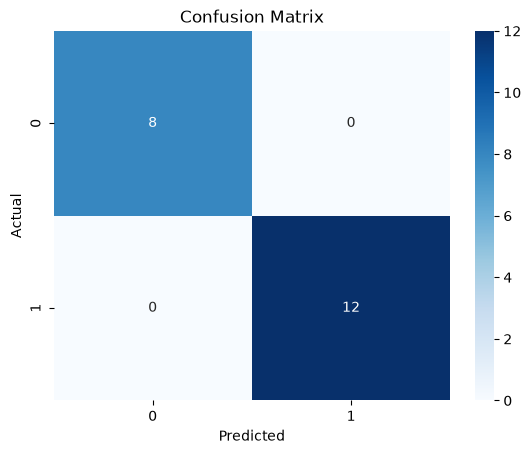

In [33]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [34]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00         8
           1       1.00      1.00      1.00        12

    accuracy                           1.00        20
   macro avg       1.00      1.00      1.00        20
weighted avg       1.00      1.00      1.00        20



In [35]:
# Final Model Performance Summary

print("Model Accuracy :", accuracy_score(y_test, y_pred) * 100, "%")

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Model Accuracy : 100.0 %

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         8
           1       1.00      1.00      1.00        12

    accuracy                           1.00        20
   macro avg       1.00      1.00      1.00        20
weighted avg       1.00      1.00      1.00        20



In [39]:
# New student data
new_student = [[90, 85, 80, 10]]

prediction = model.predict(new_student)

if prediction[0] == 1:
    print("Student is likely to PASS")
else:
    print("Student is likely to FAIL")
    

Student is likely to PASS


c:\Users\ASUS\OneDrive\Desktop\Microsoft_Training\Machine_Learning\.venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


In [40]:
import pandas as pd

new_student = pd.DataFrame({
    "Attendance_pt": [90],
    "Homework_%": [85],
    "Midterm__Score": [80],
    "StudyHoursPerWeek": [10]
})

prediction = model.predict(new_student)

print(prediction)

[1]


In [41]:
prediction = model.predict(new_student)

if prediction[0] == 1:
    print("Student is likely to PASS")
else:
    print("Student is likely to FAIL")

Student is likely to PASS


In [42]:
probability = model.predict_proba(new_student)

print("Probability of Fail :", round(probability[0][0]*100,2), "%")
print("Probability of Pass :", round(probability[0][1]*100,2), "%")

Probability of Fail : 0.0 %
Probability of Pass : 100.0 %
